In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import jax.numpy as jnp
import numpy as np
import seaborn as snb
from typing import NamedTuple
from typing import Tuple

from scipy.stats import binom as binom_dist
from scipy.stats import beta as beta_dist
from scipy.special import beta as beta_fun
from scipy.special import gamma
from scipy.special import comb

snb.set_style('darkgrid')
snb.set(font_scale=1.5)
plt.rcParams['lines.linewidth'] = 3


# Part 1) The beta-binomial model

Your friend has set up a website for her new business. So far $N = 115$ potential customers has visited her
site, but only $y = 4$ customers have completed a purchase. To plan her future investments, she asks you
for help to compute the probability that at least one of the next $N^∗ = 20$ customers will make a purchase.
You decide to model the problem using the beta-binomial model with a uniform prior distribution on the
probability of making a purchase $\theta \in [0, 1]$:

$$\begin{align}
\theta &∼ \text{Beta}(a_0, b_0) \\
y|\theta &∼ \text{Binomial}(N, \theta) \\
\end{align}$$

where $a_0 = b_0 = 1$

In [2]:
a0 = b0 = 1
y = 4
N = 115

## Task 1.1) Compute the prior mean of $\theta$ and provide a 95% interval for the prior
As the Beta distribution is a distribution in the interval $[0,1]$, and is symmetric and equiprobable over it when $a=b=1$, it is easy to see that the prior mean is 0.5. Formally, the mean of the beta distribution is $\frac{\alpha}{\alpha + \beta}$, and we can calculate it easily as:
$$ \mathbb{E}[\theta] = \frac{\alpha}{\alpha + \beta} = 0.5 $$

The same reasoning can be done for the 95% credibility interval. In this case, as it is symmetric, it corresponds to $\theta\in[0.025, 0.975]$

## Task 1.2) Compute the posterior mean of $\theta$ and provide a 95% credibility interval for the posterior

For this, we must compute the posterior $p(\theta|y)\propto p(y|\theta)p(\theta)$. As the $\beta$ distribution is a conjugate distribution to a binomial distribution, the posterior is likewise a Beta distribution. In the exercises and in class, it was shown that the resulting posterior distribution will follow a beta distribution as follows:
$$ \begin{align}
p(\theta|y) &= \text{Beta}(\theta | a_0 + y, b_0 + N - y) \\
&= \text{Beta}(\theta | 1 + 4, 1 + 115 - 4) 
&= \text{Beta}(\theta | 5, 112) \end{align}
$$

In [3]:
a_post = a0 + y
b_post = b0 + N - y

Let $y^*$ denote the number of purchases during the next $N^*=20$ visits.
## Task 1.3) Compute and plot the posterior predictive distribution for $y^∗$ given $y = 4$.

For this task, we must compute $p(y^*|y,\theta,N^*) = \int p(y^*|\theta)p(\theta|y) \partial\theta$. When inserting the PMF for the binomial and beta distributions, it simplifies a such that the integral only has the functional form of the beta distribution left, and so the above integral will evalute to:

$$p(y^*|y,N^*) = \int p(y^*|\theta)p(\theta|y) d\theta = \binom{N^*}{k}\frac{B(\alpha+k,\beta+N^*-k)}{B(\alpha,\beta)},\text{ where } B(a, b) = \frac{\Gamma(a)\Gamma(b)}{\Gamma(a+b)} $$

In this case, we have that $N^* = 20$, and so $k\in[0,20]$.

In the plot, we see that the majority of the probability mass is centered around 0 and 1. We expect this, as only originally 4 out of the 115 customers in the original data would make a purcahse.

Sum of predictive probs: 0.9999999999999996


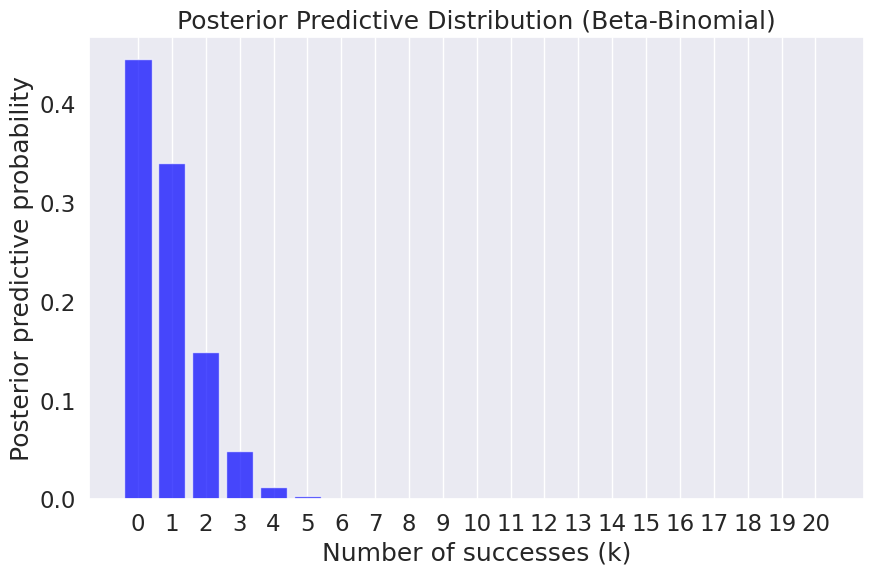

In [4]:
def beta_norm(a, b):
    return gamma(a) * gamma(b) / gamma(a + b)

N_star = 20
k = list(range(N_star + 1))
post_pred_probs = np.array([comb(N_star, k_) * (beta_norm(k_ + a_post, b_post + N_star - k_)/beta_norm(a_post, b_post)) for k_ in k])

print("Sum of predictive probs:", post_pred_probs.sum())

plt.figure(figsize=(10, 6))
plt.bar(k, post_pred_probs, color="blue", alpha=0.7)
plt.xlabel("Number of successes (k)")
plt.ylabel("Posterior predictive probability")
plt.title("Posterior Predictive Distribution (Beta-Binomial)")
plt.xticks(k)
plt.grid(axis="y")
plt.show()

## Task 1.4) What is the posterior predictive probability that at least one of the next $N^∗= 20$ customers will make a purchase?

We the predictive posterior distribution, this is easy as must simply sum up for $y = k$, for $k\geq 1$:
$$ p(y^* >= 1|y, N^*) = \sum_{k=1}^{N^*} p(y^* = k|y, N^*) = \sum_{k=1}^{N^*} \binom{N^*}{k}\frac{B(\alpha+k,\beta+N^*-k)}{B(\alpha,\beta)} \approx 55.44\%$$

In [6]:
np.sum(post_pred_probs[1:]).item()

0.5543908502644233

## Task 1.5) Compute mean and variance of the posterior predictive distribution for $y^∗$.

The mean of the binomial distribution is simply $\mathbb{E}[y^*|y,N^*] = np$. Here, however, $\theta$ is uncertain and integrated out, so $y^*|y,N^*$ follows a posterior predictive (beta-binomial) distribution. So we must do it the old fashioned way, where the mean of a stochastic discrete random variable is computed as
$$
\mathbb{E}[y^*|y,N^*] = \sum_{k=0}^{N^*} k\,p(y^*=k|y,N^*) \approx 0.855.
$$

Likewise, the variance is

$$
\begin{aligned}
\mathbb{V}[y^*|y,N^*]
&= \mathbb{E}\!\left[(y^*-\mu)^2 \mid y,N^*\right] \\
&= \mathbb{E}\!\left[(y^*)^2 \mid y,N^*\right] - \mu^2,\quad
\mu=\mathbb{E}[y^*|y,N^*] \\
&\approx 0.95.
\end{aligned}
$$

In [11]:
mu = np.sum(np.arange(len(post_pred_probs)) * post_pred_probs).item()
var = np.sum((np.arange(len(post_pred_probs)) - mu)**2 * post_pred_probs).item()
mu, var

(0.8547008547008542, 0.9499152480464949)

# Part 2) Linear Gaussian systems

Let $z_1,z_2\in\mathbb{R}^2$ and $y\in\mathbb{R}$ be random variables and consider the following linear Gaussian system:
$$ \begin{align}
z_1 &\sim \mathcal{N}(\mathbf{0}, v\mathbf{I}) \\
z_2|z_1 &\sim \mathcal{N}(z_1, v\mathbf{I}) \\
y|z_2 &\sim \mathcal{N}(\mathbf{a}^\top z_2, \sigma^2),
\end{align}$$

where $\mathbf{a}\in\mathbb{R}^2$ is a constant. The joint distribution of $(y,z_2, z_1)$ is given by
$$ p(y,z_2,z_1) = p(y|z_2)p(z_2|z_1)p(z_1) $$

## Task 2.1) Determine the distribution $p(y)$

To determine this, we must use probability rules to determine the expression for $p(y)$. If we start with equation (1) to (3), it would be beneficial to compute an expression for $p(z_2)$ first.

We see that we can write $z_2 = z_1 + e_2$ where $e_2\sim\mathcal{N}(\mathbf{0}, v\mathbf{I})$. When we do an affine transformation of multivariate Gaussian distributions, we get yet another Guassian distribution

$$ \begin{align*}
\mathbb{E}[z_1 + e_2] &= \mathbb{E}[z_1] + \mathbb{E}[e_2] = \mathbf{0} + \mathbf{0} = \mathbf{0} \\
\mathbb{V}[z_1 + e_2] &= \mathbb{V}[z_1] + \mathbb{V}[e_2] = v\mathbf{I} + v\mathbf{I} = 2v\mathbf{I}
\end{align*} $$

Note, in the above the covariance from the variance expression is left out as it zeros out. From above we now see that $z_2 \sim \mathcal{N}(\mathbf{0},2v\mathbf{I})$.

Now we can similar do $y = \mathbf{a}^\top z_2 + e_y$ where $e_y = \mathcal{N}(0, \sigma^2)$.

$$ \begin{align*}
\mathbb{E}[\mathbf{a}^\top z_2 + e_y] &= \mathbf{a}^\top\mathbb{E}[z_2] + \mathbb{E}[e_y] = \mathbf{a}^\top\mathbf{0} + 0 = 0 \\
\mathbb{V}[\mathbf{a}^\top z_2 + e_y] &= \mathbb{V}[\mathbf{a}^\top z_2] + \mathbb{V}[e_y] = \mathbf{a}^\top 2v\mathbf{I}\mathbf{a} + \sigma^2 = 2v||\mathbf{a}||_2^2 + \sigma^2,
\end{align*} $$

And so we arrive with $p(y) = \mathcal{N}(y|0, 2v||\mathbf{a}||_2^2 + \sigma^2)$



## Task 2.2) Determine the distribution $p(y,z_2|z_1)$

We can write out this joint distribution as $p(y,z_2|z_1) = p(z_2|z_1)p(y|z_2)$. This looks like the linear system described in the book by Murphy, where the joint distribution would have mean and covariance matrix described as

$$ \begin{align}
\mathbf{\mu} &= \begin{bmatrix} \mu_{z_2|z_1} \\ \mathbf{a}^\top \mu_{z_2|z_1} \end{bmatrix} = \begin{bmatrix} z_1 \\ \mathbf{a}^\top z_1 \end{bmatrix} \\
\mathbf{\Sigma} &= \begin{bmatrix} v\mathbf{I} & v\mathbf{I}\mathbf{a} \\ v\mathbf{I}\mathbf{a}^\top& \sigma^2 + \mathbf{a}(v\mathbf{I})\mathbf{a}^\top \end{bmatrix} = \begin{bmatrix} v\mathbf{I} & v\mathbf{a} \\ v\mathbf{a}^\top& \sigma^2 + v||\mathbf{a}||_2^2 \end{bmatrix} \\
\end{align} $$

and so the distribution of $p(y,z_2|z_1) = \mathcal{N}\left( \begin{bmatrix} z_2 \\ y \end{bmatrix} \middle| \begin{bmatrix} z_1 \\ \mathbf{a}^\top z_1 \end{bmatrix}, \begin{bmatrix} v\mathbf{I} & v\mathbf{a} \\ v\mathbf{a}^\top& \sigma^2 + v||\mathbf{a}||_2^2 \end{bmatrix} \right) $

## Task 2.3) Determine the distribution $p(y|z_1)$

We were smart in task 2.2 to write out the linear Gaussian system in such a way, that we can easily inspect it to determine the distribution, which is the lower element of the $\mu$ matrix, and the bottom right of the covariance matrix $\mathbf{\mathbf{\Sigma}}$:

$$ p(y|z_1) = \mathcal{N}\left(y|\mathbf{a}^\top z_1, \sigma^2 + v||\mathbf{a}||_2^2\right) $$

## Task 2.4) Determine the distribution $p(z_1|y)$

Writing this out with _Bayes' Theorem_, we get
$p(z_1|y) = \frac{p(y|z_1)p(z_1)}{p(y)}$, where the _marginal likelihood_ $p(y)$ is simply normalizing it to 1. In the book Murphy, we also get the closed form solution on the form below, where I have appropriately substitued the terms which may be relevant from task 2.3 (the variance for example $\Sigma_y$ which is the varince from task 2.3, and _not_ just the variance of $y$ ).

$$ \begin{align}
p(\mathbf{z_1}|\mathbf{y}) &= \mathcal{N}(z_1|\mathbf{\mu}_{z_1|y}, \mathbf{\Sigma}_{z_1|y}) \\
\mathbf{\Sigma}^{-1}_{z_1|y} &= (v\mathbf{I})^{-1} + \mathbf{a}(\sigma^2 + v||\mathbf{a}||_2^2)^{-1}\mathbf{a} ^\top \\
\mathbf{\mu}_{z_1|y} &= \mathbf{\Sigma}_{z_1|y}\left[ \mathbf{a}(\sigma^2 + v||\mathbf{a}||_2^2)^{-1}(y) + v\mathbf{I}\mathbf{0} \right] = \mathbf{\Sigma}_{z_1|y}\left[ \frac{y\mathbf{a}}{\sigma^2 + v||\mathbf{a}||_2^2} \right],
\end{align} $$

which is the final posterior distribution.

# Part 3) Poisson-Gamma 